<a href="https://colab.research.google.com/github/nehavaishnav/CEI_ASSIGNMENT/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# STEP 1: Install & Import Libraries
# ============================================================
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, silhouette_score)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# ============================================================
# STEP 2: Load & Explore Data
# ============================================================
df = pd.read_csv('Country-data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData Types & Nulls:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

Shape: (167, 10)

First 5 rows:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



Data Types & Nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None

Statistical Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


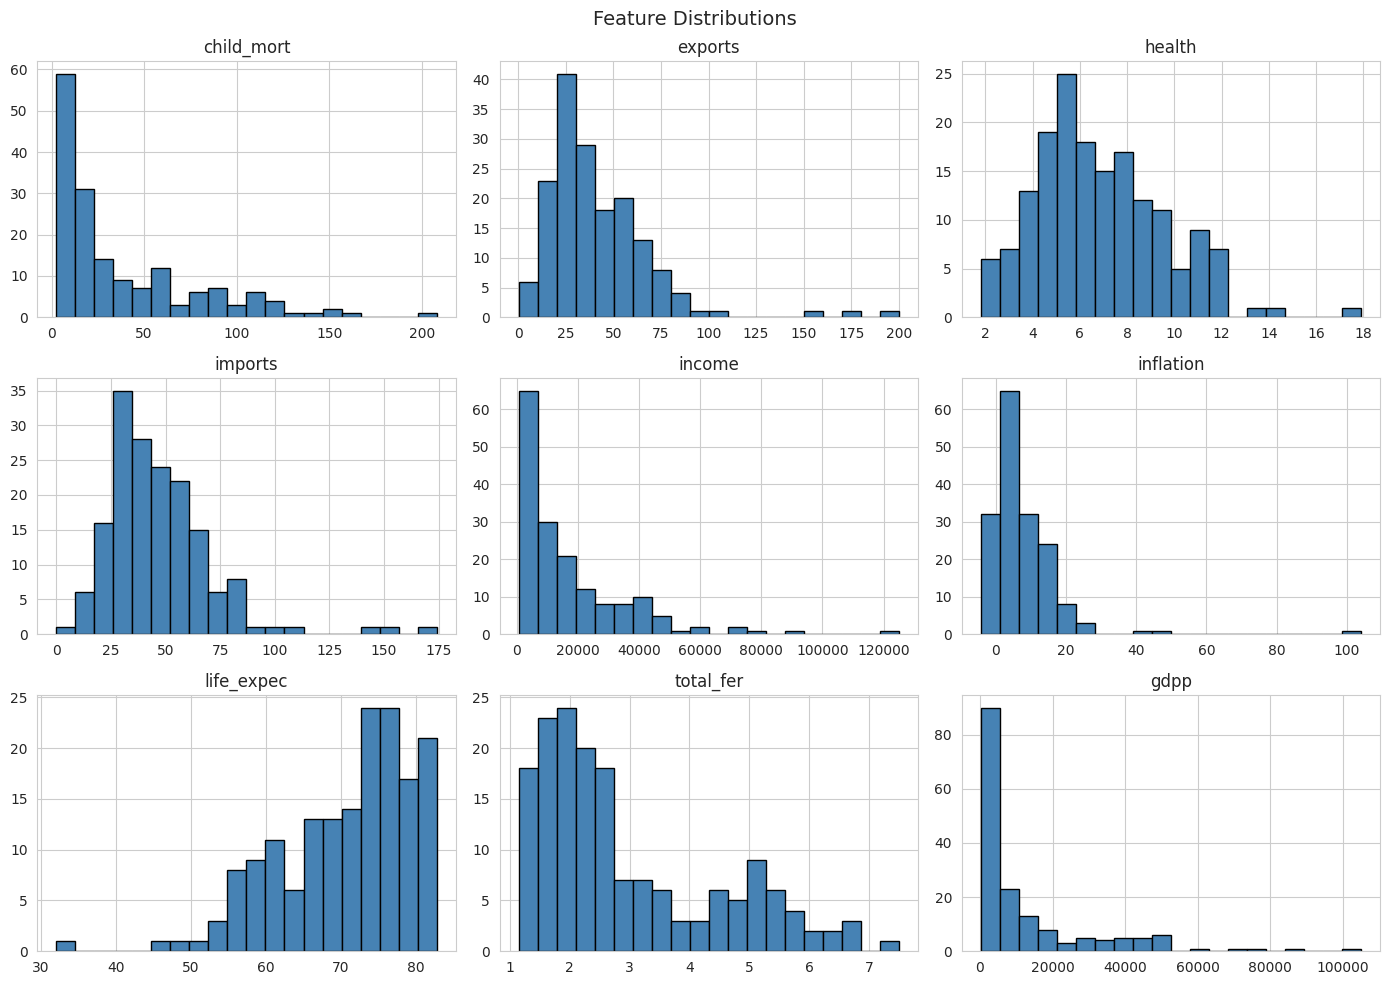

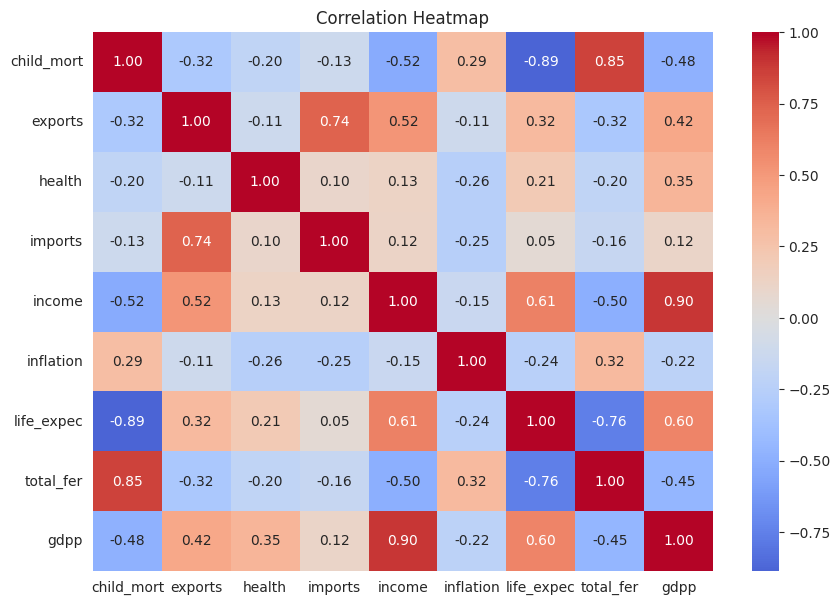

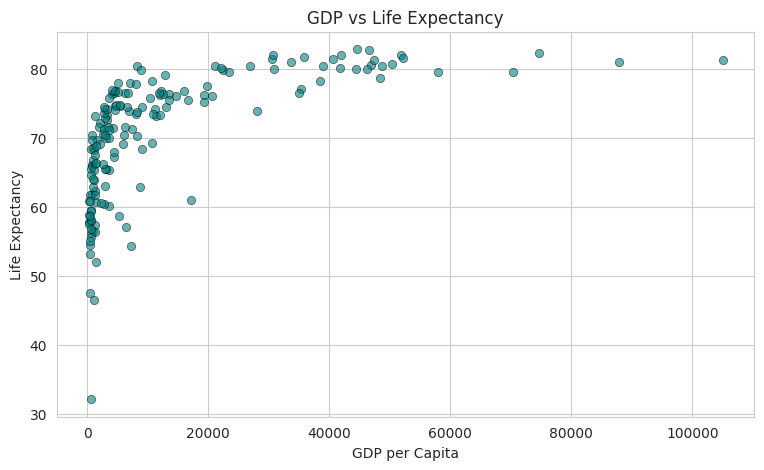

In [3]:
# ============================================================
# STEP 3: Exploratory Data Analysis
# ============================================================
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

# Distribution plots
df[features].hist(bins=20, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Scatter: GDP vs Life Expectancy
plt.figure(figsize=(9, 5))
plt.scatter(df['gdpp'], df['life_expec'], alpha=0.6, c='teal', edgecolors='k', linewidths=0.5)
plt.xlabel('GDP per Capita')
plt.ylabel('Life Expectancy')
plt.title('GDP vs Life Expectancy')
plt.show()

In [4]:
# ============================================================
# STEP 4: Feature Engineering & Target Label Creation
# ============================================================
# Create a composite "development score" to build a classification target
df['dev_score'] = (
    (df['gdpp'] / df['gdpp'].max()) * 0.3 +
    (df['life_expec'] / df['life_expec'].max()) * 0.25 +
    (1 - df['child_mort'] / df['child_mort'].max()) * 0.25 +
    (df['income'] / df['income'].max()) * 0.2
)

# Bin into 3 development classes
df['dev_label'] = pd.cut(df['dev_score'],
                          bins=3,
                          labels=['Underdeveloped', 'Developing', 'Developed'])

print("Class Distribution:")
print(df['dev_label'].value_counts())

# Additional engineered features
df['trade_balance'] = df['exports'] - df['imports']
df['health_per_income'] = df['health'] / (df['income'] + 1)

print("\nSample with new features:")
display(df[['country', 'dev_score', 'dev_label', 'trade_balance']].head(10))

Class Distribution:
dev_label
Developing        106
Underdeveloped     39
Developed          22
Name: count, dtype: int64

Sample with new features:


,country,dev_score,dev_label,trade_balance
0,Afghanistan,0.315429,Underdeveloped,-34.9
1,Albania,0.487996,Developing,-20.6
2,Algeria,0.481549,Developing,7.0
3,Angola,0.307958,Underdeveloped,19.4
4,Antigua and Barbuda,0.534921,Developing,-13.4
5,Argentina,0.520785,Developing,2.9
6,Armenia,0.469482,Developing,-24.5
7,Australia,0.706341,Developed,-1.1
8,Austria,0.691007,Developed,3.5
9,Azerbaijan,0.453806,Developing,33.6


In [5]:
# ============================================================
# STEP 5: Preprocessing
# ============================================================
feature_cols = ['child_mort', 'exports', 'health', 'imports', 'income',
                'inflation', 'life_expec', 'total_fer', 'gdpp',
                'trade_balance', 'health_per_income']

X = df[feature_cols].copy()
y = df['dev_label'].copy()

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Classes: ['Developed' 'Developing' 'Underdeveloped']

Train size: 133 | Test size: 34


=== Random Forest ===
Accuracy: 0.9412
                precision    recall  f1-score   support

     Developed       0.80      1.00      0.89         4
    Developing       0.95      0.95      0.95        22
Underdeveloped       1.00      0.88      0.93         8

      accuracy                           0.94        34
     macro avg       0.92      0.94      0.93        34
  weighted avg       0.95      0.94      0.94        34



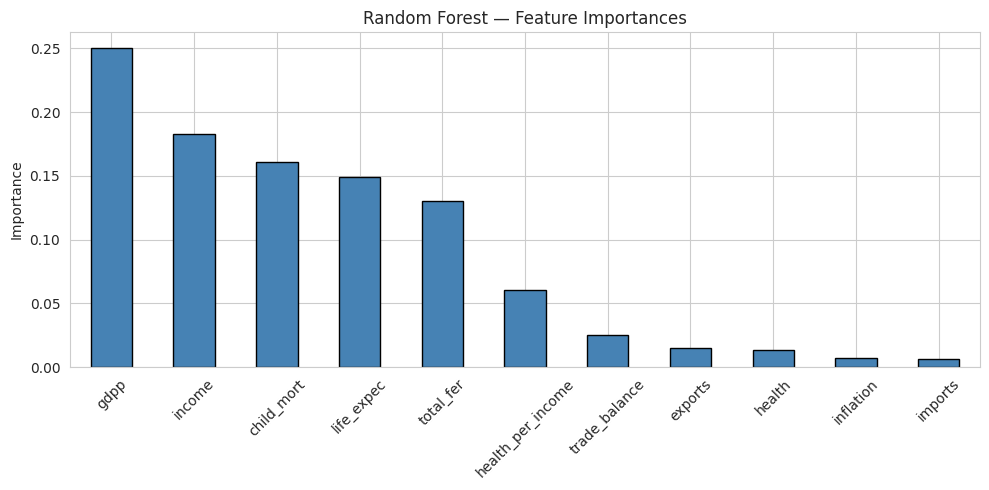

In [6]:
# ============================================================
# STEP 6: Random Forest Classifier
# ============================================================
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# STEP 7: XGBoost Classifier
# ============================================================
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                    use_label_encoder=False, eval_metric='mlogloss',
                    random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

=== XGBoost ===
Accuracy: 1.0000
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         4
    Developing       1.00      1.00      1.00        22
Underdeveloped       1.00      1.00      1.00         8

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



=== Ensemble (RF + XGBoost Soft Voting) ===
Accuracy: 1.0000
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         4
    Developing       1.00      1.00      1.00        22
Underdeveloped       1.00      1.00      1.00         8

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



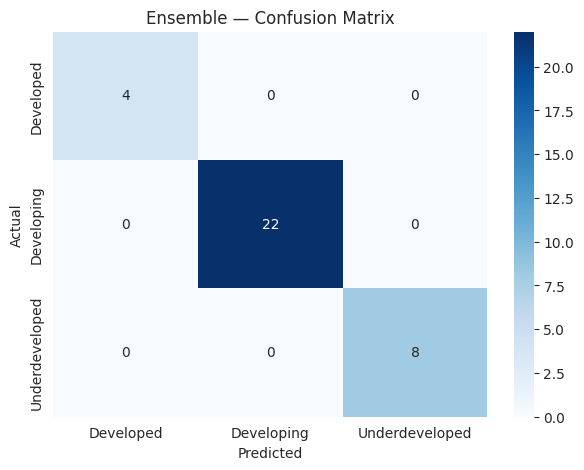

In [8]:
# ============================================================
# STEP 8: Ensemble — Soft Voting
# ============================================================
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

print("=== Ensemble (RF + XGBoost Soft Voting) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ens):.4f}")
print(classification_report(y_test, y_pred_ens, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ens)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Ensemble — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
# ============================================================
# STEP 9: Hyperparameter Tuning with GridSearchCV
# ============================================================
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# Evaluate best model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f"Test Accuracy (Tuned RF): {accuracy_score(y_test, y_pred_best):.4f}")

Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.9923
Test Accuracy (Tuned RF): 0.9706


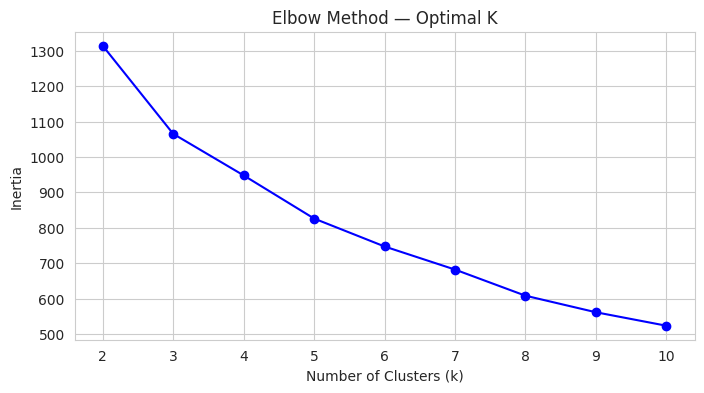

K-Means Silhouette Score (k=3): 0.2648
Cluster counts:
 kmeans_cluster
2    88
0    43
1    36
Name: count, dtype: int64


In [10]:
# ============================================================
# STEP 10: K-Means Clustering
# ============================================================
# Elbow method to find optimal k
inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.show()

# Fit with optimal k = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"K-Means Silhouette Score (k=3): {sil_score:.4f}")
print("Cluster counts:\n", df['kmeans_cluster'].value_counts())

In [11]:
# ============================================================
# STEP 11: DBSCAN Clustering
# ============================================================
dbscan = DBSCAN(eps=2.0, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = (df['dbscan_cluster'] == -1).sum()

print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points")
print("Cluster counts:\n", df['dbscan_cluster'].value_counts())

# Silhouette (exclude noise points)
mask = df['dbscan_cluster'] != -1
if mask.sum() > 1 and n_clusters > 1:
    sil_db = silhouette_score(X_scaled[mask], df['dbscan_cluster'][mask])
    print(f"DBSCAN Silhouette Score: {sil_db:.4f}")

DBSCAN found 1 clusters and 24 noise points
Cluster counts:
 dbscan_cluster
 0    143
-1     24
Name: count, dtype: int64


Explained Variance Ratio: [0.43366522 0.16522458]


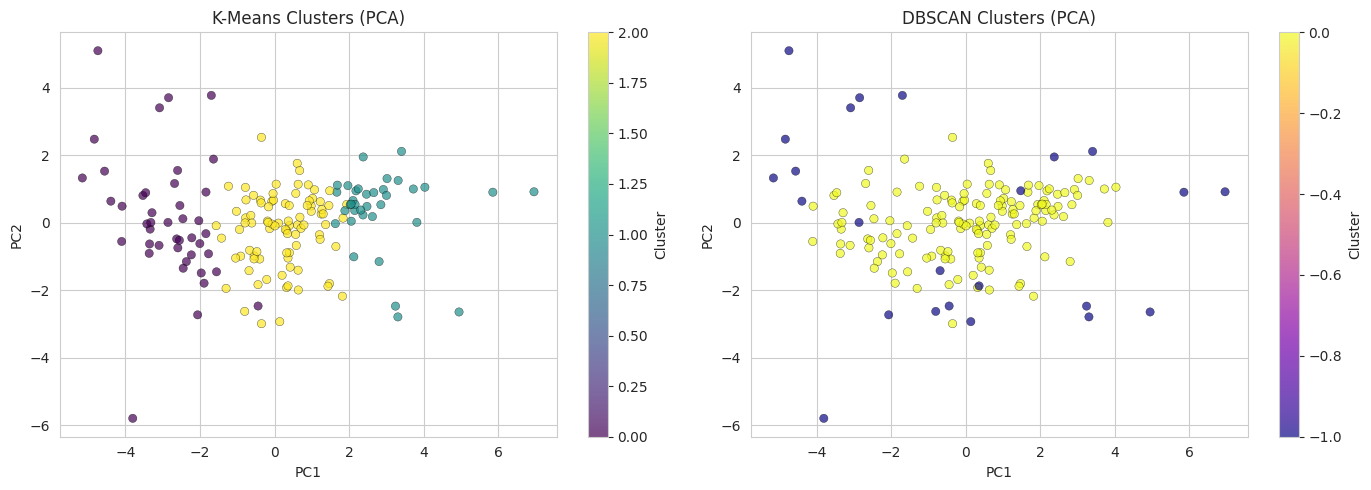

In [12]:
# ============================================================
# STEP 12: PCA — Visualize Clusters in 2D
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['kmeans_cluster'], cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.3)
axes[0].set_title('K-Means Clusters (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

# DBSCAN
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['dbscan_cluster'], cmap='plasma', alpha=0.7, edgecolors='k', linewidths=0.3)
axes[1].set_title('DBSCAN Clusters (PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

=== K-Means Cluster Profiles ===


,gdpp,life_expec,child_mort,income,health
kmeans_cluster,,,,,
0,1378.84,59.40,94.98,2825.42,6.65
1,42494.44,80.13,5.00,45672.22,8.81
2,6544.59,72.09,24.17,12471.25,6.08


,gdpp,life_expec,child_mort,dev_level
kmeans_cluster,,,,
0,1378.84,59.40,94.98,Underdeveloped
1,42494.44,80.13,5.00,Developed
2,6544.59,72.09,24.17,Developing


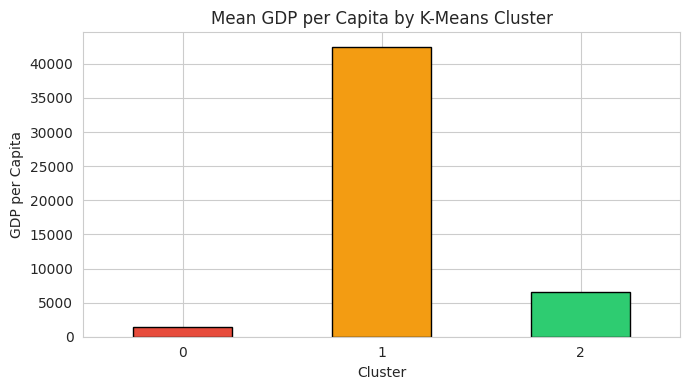

In [13]:
# ============================================================
# STEP 13: Cluster Profiling — Business Insights
# ============================================================
cluster_profile = df.groupby('kmeans_cluster')[
    ['gdpp', 'life_expec', 'child_mort', 'income', 'health']
].mean().round(2)

print("=== K-Means Cluster Profiles ===")
display(cluster_profile)

# Label clusters by development level
cluster_profile['dev_level'] = cluster_profile['gdpp'].rank().map(
    {1.0: 'Underdeveloped', 2.0: 'Developing', 3.0: 'Developed'})
display(cluster_profile[['gdpp', 'life_expec', 'child_mort', 'dev_level']])

# Bar chart of mean GDP by cluster
cluster_profile['gdpp'].plot(kind='bar', color=['#e74c3c', '#f39c12', '#2ecc71'],
                              edgecolor='black', figsize=(7, 4))
plt.title('Mean GDP per Capita by K-Means Cluster')
plt.ylabel('GDP per Capita')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Model,Test Accuracy
1,XGBoost,1.000000
2,Ensemble (RF+XGB),1.000000
3,Tuned RF,0.970588
0,Random Forest,0.941176


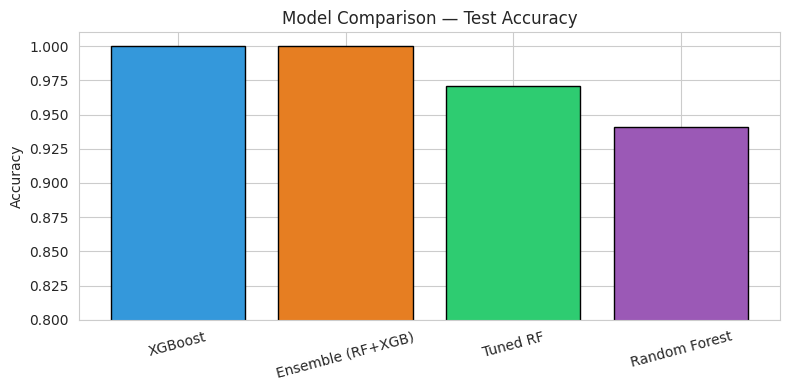


✅ Customer Intelligence System Complete!


In [14]:
# ============================================================
# STEP 14: Final Model Comparison Summary
# ============================================================
results = {
    'Model': ['Random Forest', 'XGBoost', 'Ensemble (RF+XGB)', 'Tuned RF'],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_ens),
        accuracy_score(y_test, y_pred_best)
    ]
}

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
display(results_df)

# Bar chart
plt.figure(figsize=(8, 4))
plt.bar(results_df['Model'], results_df['Test Accuracy'],
        color=['#3498db', '#e67e22', '#2ecc71', '#9b59b6'], edgecolor='black')
plt.ylim(0.8, 1.01)
plt.ylabel('Accuracy')
plt.title('Model Comparison — Test Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\n✅ Customer Intelligence System Complete!")